<a href="https://colab.research.google.com/github/chizkidd/transformers-from-scratch/blob/main/gpt1-sentiment-analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

![](https://miro.medium.com/v2/resize:fit:1400/1*VW_RpMfHV4TYcAoYVS3ZEQ.png)

Transformer Models: A collection of various transformer architectures, models, & their implementations-from-scratch (`PyTorch`) in Jupyter Notebooks.
* Author: _Chizoba Obasi_
* Github Repo: https://github.com/chizkidd/transformers-from-scratch
---


In [1]:
%%capture
!pip install watermark
!pip install torchinfo
!pip install datasets


In [2]:
%load_ext watermark
%watermark -a 'Chizoba Obasi' -v -p torch


Author: Chizoba Obasi

Python implementation: CPython
Python version       : 3.12.13
IPython version      : 7.34.0

torch: 2.10.0+cu128



# GPT-1: Improving Language Understanding by Generative Pre-Training
---

This notebook implements **GPT-1** **[1]** from scratch, evolving from the Transformer Decoder
into a **decoder-only** autoregressive language model with discriminative fine-tuning.

The implementation has **two phases:**

1. **Phase 1 — Generative Pre-training:** Train a 12-layer decoder-only Transformer on
   **BookCorpus** (via WikiText-2 proxy) using a standard **causal language modeling** objective
   — predict the next token given all previous tokens.

2. **Phase 2 — Discriminative Fine-tuning:** Adapt the pre-trained model to **SST-2**
   (sentiment classification) by adding a linear classification head on the **last token**,
   with an **auxiliary LM loss** to improve generalization (as described in the GPT-1 paper).

<br>

### GPT-1 Architecture

![](https://upload.wikimedia.org/wikipedia/commons/thumb/5/51/Full_GPT_architecture.svg/1920px-Full_GPT_architecture.svg.png)

([Source](https://en.wikipedia.org/wiki/GPT-1))

<br>

### Key Differences: BERT (Encoder-Only) → GPT-1 (Decoder-Only)

| Feature | BERT | GPT-1 |
| :--- | :--- | :--- |
| **Architecture** | Encoder only (bidirectional) | **Decoder only** (causal/left-to-right) |
| **Attention mask** | Padding mask only | **Causal mask** (lower triangular) |
| **Pre-training** | MLM + NSP (predict masked tokens) | **Autoregressive LM** (predict next token) |
| **Segment embeddings** | Yes (sentence A vs B) | **No** (single sequence) |
| **Fine-tuning output** | `[CLS]` token (position 0) | **Last token** (final position) |
| **Auxiliary loss** | None | **LM loss** added during fine-tuning |
| **Generation** | Cannot generate (bidirectional) | **Can generate** text autoregressively |

<br>

### More Detailed Comparison Table

| Component | BERT | GPT-1 |
| :--- | :--- | :--- |
| **Core block** | `EncoderLayer` (bidirectional self-attn) | `DecoderLayer` (causal self-attn only, no cross-attn) |
| **Mask** | Padding mask only | **Causal + padding** (lower triangular `torch.tril`) |
| **Embeddings** | token + position + segment | token + position only (**no segment**) |
| **LM head** | Separate `mlm_head` MLP | **Weight-tied** with `token_embedding` |
| **Pre-training data** | MLM+NSP pairs with `[CLS] A [SEP] B [SEP]` | Contiguous text chunks `[BOS] tokens [EOS]`, targets shifted by 1 |
| **Pre-training loss** | `MLM + NSP` (two CrossEntropy) | Single autoregressive CrossEntropy |
| **Pre-training metrics** | MLM acc, NSP acc | **Loss + Perplexity** (standard LM metrics) |
| **Fine-tuning input** | `[CLS] sent [SEP]`, classify from position 0 | `[BOS] sent [CLF]`, classify from **last** position |
| **Fine-tuning loss** | `CrossEntropy` only | `L_task + 0.5 * L_LM` (**auxiliary LM loss**) |
| **Generation** | Not possible | `generate_text()` with **top-k sampling** |
| **Special tokens** | `[CLS]`/`[SEP]`/`[MASK]` | `[BOS]`/`[EOS]`/`[CLF]` |

<br>

### The Autoregressive Objective

$$L_{LM} = -\sum_{i} \log P(u_i \mid u_{i-k}, \ldots, u_{i-1}; \Theta)$$

### Fine-tuning with Auxiliary LM Loss

$$L_{total} = L_{task}(y \mid x) + \lambda \cdot L_{LM}(x)$$

where $\lambda = 0.5$ in the original paper.

<br>

---

**REFERENCES:**

1. Radford, Alec, et al. ["Improving Language Understanding by Generative Pre-Training."](https://cdn.openai.com/research-covers/language-unsupervised/language_understanding_paper.pdf) *OpenAI*, 2018.
2. Vaswani, Ashish, et al. ["Attention is all you need."](https://arxiv.org/abs/1706.03762) *NeurIPS*, 2017.
3. Devlin, Jacob, et al. ["BERT: Pre-training of Deep Bidirectional Transformers."](https://arxiv.org/abs/1810.04805) *NAACL*, 2019.

---


In [3]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence
from datasets import load_dataset
from collections import Counter

from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

from torch.amp import GradScaler, autocast
from torchinfo import summary

import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

import numpy as np
import math
import time
import os
import random
import re

if torch.cuda.is_available():
    torch.backends.cudnn.deterministic = True


In [4]:
def set_all_seeds(seed):
    os.environ["PL_GLOBAL_SEED"] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)


---
# 0. Hyperparameters
---


In [5]:
##########################
### SETTINGS
##########################

RANDOM_SEED = 123
set_all_seeds(RANDOM_SEED)

# Vocabulary
VOCABULARY_SIZE = 30000 # 10000  -> Reduce OOV tokens, better coverage

# GPT-1 Architecture (scaled for training feasibility)
D_MODEL = 768
N_LAYERS = 12
N_HEADS = 12
D_FF = 4 * D_MODEL
DROPOUT = 0.1
MAX_LEN = 128 # -> More context for sentiment (if GPU allows)

# Pre-training (Autoregressive LM)
PRETRAIN_EPOCHS = 15 #10
PRETRAIN_BATCH_SIZE = 64
PRETRAIN_LR = 2.5e-4  # GPT-1 used 2.5e-4

# Fine-tuning
FINETUNE_EPOCHS = 5 # 15 #10 -> Paper says 3 epochs sufficient, prevent overfit
FINETUNE_BATCH_SIZE = 32
FINETUNE_LR = 6.25e-5  # GPT-1 used 6.25e-5
AUX_LM_WEIGHT = 0.1 # 0.5    # Lambda for auxiliary LM loss -> 0.5 is overwhelming task loss
PATIENCE = 3

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")


Device: cuda


---
# 1. Data Preparation & Vocabulary

GPT-1 was pre-trained on **BookCorpus** (~7000 unpublished books).
Since BookCorpus is no longer publicly available, we use **WikiText-2** as a proxy corpus.
The vocabulary and fine-tuning dataset (SST-2) are built from this shared pipeline.

---


In [6]:
# ==========================================
# 1a. Load Datasets
# ==========================================

# Pre-training corpus (WikiText-2 as BookCorpus proxy)
wiki_dataset = load_dataset("wikitext", "wikitext-2-raw-v1")

# Fine-tuning dataset (SST-2 from GLUE)
sst2_dataset = load_dataset("glue", "sst2")

print(f"WikiText-2 samples - train: {len(wiki_dataset['train'])}, val: {len(wiki_dataset['validation'])}, test: {len(wiki_dataset['test'])}")
print(f"SST-2 samples - train: {len(sst2_dataset['train'])}, val: {len(sst2_dataset['validation'])}")


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


WikiText-2 samples - train: 36718, val: 3760, test: 4358
SST-2 samples - train: 67349, val: 872


In [7]:
# ==========================================
# 1b. Tokenizer & Vocabulary
# ==========================================

# def tokenizer(text):
#     """Simple word-level tokenizer with punctuation splitting."""
#     return re.findall(r"[\w']+|[.,!?;:\-]", text.lower())

def tokenizer(text):
    text = text.lower()
    text = re.sub(r'([.,!?;:\-])', r' \1 ', text)
    return text.split()

# GPT-1 Special Tokens
SPECIAL_TOKENS = ['[PAD]', '[UNK]', '[BOS]', '[EOS]', '[CLF]']
PAD_IDX, UNK_IDX, BOS_IDX, EOS_IDX, CLF_IDX = 0, 1, 2, 3, 4
# [BOS] = beginning of sequence
# [EOS] = end of sequence
# [CLF] = classification token (appended at end for fine-tuning)

# Build vocab from WikiText-2
word_counts = Counter()
for item in wiki_dataset['train']:
    text = item['text'].strip()
    if len(text) > 0:
        word_counts.update(tokenizer(text))

vocab = {word: i for i, word in enumerate(SPECIAL_TOKENS)}
for word, _ in word_counts.most_common(VOCABULARY_SIZE - len(SPECIAL_TOKENS)):
    if word not in vocab:
        vocab[word] = len(vocab)

inv_vocab = {v: k for k, v in vocab.items()}

ACTUAL_VOCAB_SIZE = len(vocab)
print(f"Vocabulary size: {ACTUAL_VOCAB_SIZE}")
print(f"Special tokens: {SPECIAL_TOKENS}")
print(f"Sample tokens: {list(vocab.keys())[5:20]}")


Vocabulary size: 30000
Special tokens: ['[PAD]', '[UNK]', '[BOS]', '[EOS]', '[CLF]']
Sample tokens: ['the', ',', '.', 'of', 'and', '@', 'in', 'to', 'a', '=', '"', 'was', '-', 'on', 'as']


---
# 1c. Pre-training Data Pipeline (Causal LM)

Unlike BERT (which masks random tokens), GPT-1 uses a standard **autoregressive** objective:
given tokens $u_1, u_2, \ldots, u_{i-1}$, predict $u_i$.

Each training sample is a contiguous chunk of text:
`[BOS] token_1 token_2 ... token_n [EOS]`

The model predicts each token shifted by one position.

---


In [8]:
# ==========================================
# 1c. Pre-training Dataset (Causal LM)
# ==========================================

class GPTPretrainDataset(Dataset):
    """
    Autoregressive LM dataset for GPT-1 pre-training.
    Chunks text into fixed-length sequences with [BOS] and [EOS].
    Input:  [BOS] t1 t2 ... t_{n-1}
    Target:  t1  t2 t3 ... t_n  (shifted by 1)
    """
    def __init__(self, text_dataset, vocab, max_len=128):
        super().__init__()
        self.max_len = max_len
        self.vocab = vocab

        # Concatenate all text into a single token stream
        all_tokens = []
        for item in text_dataset:
            text = item['text'].strip()
            if len(text) > 10:
                tokens = [vocab.get(t, UNK_IDX) for t in tokenizer(text)]
                all_tokens.extend(tokens)

        # Chunk into sequences of max_len (with room for [BOS] and [EOS])
        chunk_size = max_len - 2  # Reserve space for [BOS] and [EOS]
        self.samples = []
        for i in range(0, len(all_tokens) - chunk_size, chunk_size):
            chunk = all_tokens[i:i + chunk_size]
            # Input:  [BOS] chunk
            # Target: chunk [EOS]
            input_ids = [BOS_IDX] + chunk
            target_ids = chunk + [EOS_IDX]
            self.samples.append((input_ids, target_ids))

        print(f"  GPTPretrainDataset: {len(self.samples)} samples from {len(all_tokens):,} tokens.")

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        inp, tgt = self.samples[idx]
        return torch.tensor(inp, dtype=torch.long), torch.tensor(tgt, dtype=torch.long)


def pretrain_collate_fn(batch):
    inputs, targets = zip(*batch)
    inputs = pad_sequence(inputs, batch_first=True, padding_value=PAD_IDX)
    targets = pad_sequence(targets, batch_first=True, padding_value=-100)  # ignore padding in loss
    return inputs, targets


In [9]:
# Build Pre-training DataLoaders
pretrain_train_dataset = GPTPretrainDataset(wiki_dataset['train'], vocab, max_len=MAX_LEN)
pretrain_val_dataset   = GPTPretrainDataset(wiki_dataset['validation'], vocab, max_len=MAX_LEN)

pretrain_train_loader = DataLoader(
    pretrain_train_dataset, batch_size=PRETRAIN_BATCH_SIZE,
    shuffle=True, collate_fn=pretrain_collate_fn, num_workers=0
)
pretrain_val_loader = DataLoader(
    pretrain_val_dataset, batch_size=PRETRAIN_BATCH_SIZE,
    shuffle=False, collate_fn=pretrain_collate_fn, num_workers=0
)

# Sanity check
sample_in, sample_tgt = next(iter(pretrain_train_loader))
print(f"Batch shapes — input: {sample_in.shape}, target: {sample_tgt.shape}")
print(f"Train batches: {len(pretrain_train_loader)}, Val batches: {len(pretrain_val_loader)}")

# Show example
print(f"\nExample input:  {[inv_vocab.get(t.item(), '?') for t in sample_in[0][:10]]}")
print(f"Example target: {[inv_vocab.get(t.item(), '?') for t in sample_tgt[0][:10] if t.item() != -100]}")


  GPTPretrainDataset: 16712 samples from 2,105,796 tokens.
  GPTPretrainDataset: 1745 samples from 219,976 tokens.
Batch shapes — input: torch.Size([64, 127]), target: torch.Size([64, 127])
Train batches: 262, Val batches: 28

Example input:  ['[BOS]', 'were', 'anticipated', 'for', '2016', '.', '=', '=', 'critical', 'reception']
Example target: ['were', 'anticipated', 'for', '2016', '.', '=', '=', 'critical', 'reception', '=']


---
# 2. GPT-1 Model Architecture

We reuse `MultiHeadAttention` and `PositionwiseFeedForward` from the Transformer/BERT notebooks,
but create a **`DecoderLayer`** with **causal self-attention** (no cross-attention, no bidirectional context).

Key GPT-1 specifics:
1. **Causal (lower-triangular) mask** — each token can only attend to itself and tokens before it
2. **No segment embeddings** — single contiguous sequence
3. **Learned positional embeddings** (same as BERT)
4. **GELU activation** in FFN
5. **LM head with weight tying** — shares weights with token embedding

---


In [10]:
# ==========================================
# 2a. Multi-Head Attention (from Transformer notebook)
# ==========================================

class MultiHeadAttention(nn.Module):
    def __init__(self, d_model, n_heads, dropout=0.1):
        super().__init__()
        assert d_model % n_heads == 0, "d_model must be divisible by n_heads"

        self.d_model = d_model
        self.n_heads = n_heads
        self.d_k = d_model // n_heads

        self.w_q = nn.Linear(d_model, d_model)
        self.w_k = nn.Linear(d_model, d_model)
        self.w_v = nn.Linear(d_model, d_model)
        self.fc_out = nn.Linear(d_model, d_model)

        self.dropout = nn.Dropout(dropout)
        self.scale = math.sqrt(self.d_k)

    def forward(self, query, key, value, mask=None):
        batch_size = query.shape[0]

        Q = self.w_q(query).view(batch_size, -1, self.n_heads, self.d_k).transpose(1, 2)
        K = self.w_k(key).view(batch_size, -1, self.n_heads, self.d_k).transpose(1, 2)
        V = self.w_v(value).view(batch_size, -1, self.n_heads, self.d_k).transpose(1, 2)

        energy = torch.matmul(Q, K.transpose(-2, -1)) / self.scale

        if mask is not None:
            energy = energy.masked_fill(mask == 0, float('-inf'))

        attention = torch.softmax(energy, dim=-1)
        x = torch.matmul(self.dropout(attention), V)

        x = x.transpose(1, 2).contiguous().view(batch_size, -1, self.d_model)
        return self.fc_out(x)


In [11]:
# ==========================================
# 2b. Feed-Forward Network (GELU, same as BERT)
# ==========================================

class PositionwiseFeedForward(nn.Module):
    def __init__(self, d_model, d_ff, dropout=0.1):
        super().__init__()
        self.fc1 = nn.Linear(d_model, d_ff)
        self.fc2 = nn.Linear(d_ff, d_model)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        return self.fc2(self.dropout(F.gelu(self.fc1(x))))


In [12]:
# ==========================================
# 2c. Decoder Layer (Causal Self-Attention Only)
# ==========================================

class DecoderLayer(nn.Module):
    """
    GPT-1 Decoder Layer.
    Unlike the Transformer decoder, there is NO cross-attention — only
    causal (masked) self-attention + feed-forward.
    """
    def __init__(self, d_model, n_heads, d_ff, dropout):
        super().__init__()
        self.self_attn = MultiHeadAttention(d_model, n_heads, dropout)
        self.feed_forward = PositionwiseFeedForward(d_model, d_ff, dropout)
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x, mask):
        # Causal Self-Attention + Residual + LayerNorm
        _x = self.self_attn(x, x, x, mask)
        x = self.norm1(x + self.dropout(_x))

        # Feed-Forward + Residual + LayerNorm
        _x = self.feed_forward(x)
        x = self.norm2(x + self.dropout(_x))
        return x


In [13]:
# ==========================================
# 2d. GPT-1 Model
# ==========================================

class GPT(nn.Module):
    """
    GPT-1: Generative Pre-trained Transformer (decoder-only).

    Key differences from BERT:
    - Causal (lower-triangular) mask for autoregressive prediction
    - No segment embeddings (single contiguous sequence)
    - LM head with weight tying to token embedding
    - Output at LAST token for classification (not [CLS] at position 0)
    """
    def __init__(self, vocab_size, d_model, n_layers, n_heads, d_ff,
                 dropout, max_len, pad_idx, device):
        super().__init__()
        self.pad_idx = pad_idx
        self.d_model = d_model
        self.device = device

        # --- GPT Embeddings (Learned positional, NO segment) ---
        self.token_embedding = nn.Embedding(vocab_size, d_model, padding_idx=pad_idx)
        self.position_embedding = nn.Embedding(max_len, d_model)
        self.embed_dropout = nn.Dropout(dropout)

        # --- Decoder Stack (causal self-attention only) ---
        self.decoder_layers = nn.ModuleList([
            DecoderLayer(d_model, n_heads, d_ff, dropout)
            for _ in range(n_layers)
        ])

        self.final_norm = nn.LayerNorm(d_model)

        # --- LM Head (weight-tied with token embedding) ---
        self.lm_head = nn.Linear(d_model, vocab_size, bias=False)
        self.lm_head.weight = self.token_embedding.weight  # Weight tying

    def make_causal_mask(self, input_ids):
        """
        Combined padding + causal mask.
        Causal: each position can only attend to itself and earlier positions.
        """
        batch_size, seq_len = input_ids.size()

        # Padding mask: [batch, 1, 1, seq_len]
        pad_mask = (input_ids != self.pad_idx).unsqueeze(1).unsqueeze(2)

        # Causal mask: [1, 1, seq_len, seq_len]
        causal_mask = torch.tril(torch.ones(seq_len, seq_len, device=input_ids.device)).bool()
        causal_mask = causal_mask.unsqueeze(0).unsqueeze(0)

        return pad_mask & causal_mask

    def get_embeddings(self, input_ids):
        """GPT embedding = token + position (no segment), then dropout."""
        seq_len = input_ids.size(1)
        positions = torch.arange(seq_len, device=input_ids.device).unsqueeze(0)

        tok_emb = self.token_embedding(input_ids) * math.sqrt(self.d_model)
        pos_emb = self.position_embedding(positions)

        return self.embed_dropout(tok_emb + pos_emb)

    def forward(self, input_ids):
        """
        Forward pass. Returns lm_logits [batch, seq_len, vocab_size].
        """
        mask = self.make_causal_mask(input_ids)
        x = self.get_embeddings(input_ids)

        for layer in self.decoder_layers:
            x = layer(x, mask)

        x = self.final_norm(x)
        return self.lm_head(x)  # [batch, seq_len, vocab_size]

    def get_hidden_states(self, input_ids):
        """Returns hidden states (for fine-tuning heads)."""
        mask = self.make_causal_mask(input_ids)
        x = self.get_embeddings(input_ids)

        for layer in self.decoder_layers:
            x = layer(x, mask)

        return self.final_norm(x)

def initialize_weights(m):
    if hasattr(m, 'weight') and m.weight.dim() > 1:
        nn.init.normal_(m.weight, mean=0.0, std=0.02)
    if hasattr(m, 'bias') and m.bias is not None:
        nn.init.constant_(m.bias, 0.0)

In [14]:
def count_parameters(model):
    """Parameter breakdown for GPT-1."""
    def count(m): return sum(p.numel() for p in m.parameters() if p.requires_grad)

    emb = count(model.token_embedding) + count(model.position_embedding)
    dec = count(model.decoder_layers)
    norm = count(model.final_norm)
    # LM head is weight-tied, so 0 extra params
    total = count(model)

    print(f"{'Component':<25} | {'Parameters':<12}")
    print("-" * 42)
    print(f"{'Embeddings (tok+pos)':<25} | {emb:,}")
    print(f"{'Decoder Stack (N Layers)':<25} | {dec:,}")
    print(f"{'Final LayerNorm':<25} | {norm:,}")
    print(f"{'LM Head (weight-tied)':<25} | 0 (shared)")
    print("-" * 42)
    print(f"{'TOTAL TRAINABLE':<25} | {total:,}")


---
# 3. Phase 1 — Generative Pre-training (Causal LM)

---


In [15]:
# ==========================================
# 3a. Pre-training Evaluation + Training Loop
# ==========================================

def evaluate_lm(model, data_loader, criterion, device):
    """Evaluate causal LM. Returns avg loss and perplexity."""
    model.eval()
    total_loss = 0.0
    total_tokens = 0

    with torch.no_grad():
        for inputs, targets in data_loader:
            inputs = inputs.to(device)
            targets = targets.to(device)

            logits = model(inputs)
            loss = criterion(logits.view(-1, logits.size(-1)), targets.view(-1))

            n_tokens = (targets != -100).sum().item()
            total_loss += loss.item() * n_tokens
            total_tokens += n_tokens

    avg_loss = total_loss / max(total_tokens, 1)
    ppl = math.exp(min(avg_loss, 100))
    return avg_loss, ppl


def pretrain_gpt(model, train_loader, val_loader, num_epochs, lr, device, patience=5, grad_accum_steps=8):
    """
    GPT-1 pre-training loop with causal LM objective.
    Mirrors the train_transformer / pretrain_bert structure.
    """
    optimizer = optim.AdamW(model.parameters(), lr=lr, betas=(0.9, 0.999), weight_decay=0.01)
    # scheduler = optim.lr_scheduler.OneCycleLR(
    #     optimizer, max_lr=lr, steps_per_epoch=len(train_loader), epochs=num_epochs
    # )

    warmup_steps = 2000
    total_steps = len(train_loader) * num_epochs
    scheduler = torch.optim.lr_scheduler.SequentialLR(
        optimizer,
        schedulers=[
            torch.optim.lr_scheduler.LinearLR(optimizer, start_factor=1e-8, end_factor=1.0, total_iters=warmup_steps),
            torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=total_steps - warmup_steps)
        ],
        milestones=[warmup_steps]
    )
    # reduction='none' so we can correctly average over non-padding tokens
    criterion = nn.CrossEntropyLoss(ignore_index=-100)

    use_amp = (device.type == 'cuda')
    scaler = GradScaler('cuda', enabled=use_amp)

    best_val_loss = float('inf')
    epochs_no_improve = 0
    start_time = time.time()

    history = {'train_loss': [], 'val_loss': [], 'train_ppl': [], 'val_ppl': [], 'lrs': []}

    print(f"Starting GPT-1 pre-training on {device}...")
    print(f"Epochs: {num_epochs} | Batches/epoch: {len(train_loader)} | LR: {lr} | Patience: {patience}")
    print("-" * 100)

    for epoch in range(num_epochs):
        model.train()
        epoch_loss = 0.0
        epoch_tokens = 0

        # Inside the training loop, replace the optimizer step section:
        for step, (inputs, targets) in enumerate(train_loader):
            inputs = inputs.to(device, non_blocking=True)
            targets = targets.to(device, non_blocking=True)

            # Only zero grads every grad_accum_steps
            if step % grad_accum_steps == 0:
                optimizer.zero_grad(set_to_none=True)

            with autocast('cuda', enabled=use_amp):
                logits = model(inputs)
                loss = criterion(logits.view(-1, logits.size(-1)), targets.view(-1))
                loss = loss / grad_accum_steps  # Scale loss for accumulation

            scaler.scale(loss).backward()

            # Only step optimizer every grad_accum_steps
            if (step + 1) % grad_accum_steps == 0:
                scaler.unscale_(optimizer)
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                scaler.step(optimizer)
                scaler.update()
                scheduler.step()

            n_tokens = (targets != -100).sum().item()
            epoch_loss += loss.item() * grad_accum_steps * n_tokens
            epoch_tokens += n_tokens

        # for inputs, targets in train_loader:
        #     inputs = inputs.to(device, non_blocking=True)
        #     targets = targets.to(device, non_blocking=True)

        #     optimizer.zero_grad(set_to_none=True)

        #     with autocast('cuda', enabled=use_amp):
        #         logits = model(inputs)
        #         loss = criterion(logits.view(-1, logits.size(-1)), targets.view(-1))

        #     scaler.scale(loss).backward()
        #     scaler.unscale_(optimizer)
        #     torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        #     scaler.step(optimizer)
        #     scaler.update()
        #     scheduler.step()

        #     n_tokens = (targets != -100).sum().item()
        #     epoch_loss += loss.item() * n_tokens
        #     epoch_tokens += n_tokens

        # --- Epoch stats ---
        t_loss = epoch_loss / max(epoch_tokens, 1)
        t_ppl = math.exp(min(t_loss, 100))

        v_loss, v_ppl = evaluate_lm(model, val_loader, criterion, device)

        # --- Early stopping ---
        if v_loss < best_val_loss:
            best_val_loss = v_loss
            torch.save(model.state_dict(), 'gpt1_pretrained.pth')
            epochs_no_improve = 0
            status = " * (Saved Best)"
        else:
            epochs_no_improve += 1
            status = f" (No improve: {epochs_no_improve}/{patience})"

        current_lr = optimizer.param_groups[0]['lr']
        elapsed = time.time() - start_time
        tok_per_sec = epoch_tokens / elapsed

        history['train_loss'].append(t_loss)
        history['val_loss'].append(v_loss)
        history['train_ppl'].append(t_ppl)
        history['val_ppl'].append(v_ppl)
        history['lrs'].append(current_lr)

        print(f"Epoch {epoch+1:03d}/{num_epochs:03d} | "
              f"Loss (T/V): {t_loss:.4f} / {v_loss:.4f} | "
              f"PPL (T/V): {t_ppl:.2f} / {v_ppl:.2f} | "
              f"tok/s: {tok_per_sec:07.0f} | "
              f"LR: {current_lr:.6f}{status}")

        if epochs_no_improve >= patience:
            print(f"\nEarly stopping triggered.")
            break

    print(f'\nDone! Total Time: {(time.time() - start_time) / 60:.2f} min')
    model.load_state_dict(torch.load('gpt1_pretrained.pth'))
    return history


In [16]:
# ==========================================
# 3b. Initialize & Pre-train GPT-1
# ==========================================

set_all_seeds(RANDOM_SEED)

gpt_model = GPT(
    vocab_size=ACTUAL_VOCAB_SIZE,
    d_model=D_MODEL,
    n_layers=N_LAYERS,
    n_heads=N_HEADS,
    d_ff=D_FF,
    dropout=DROPOUT,
    max_len=MAX_LEN,
    pad_idx=PAD_IDX,
    device=DEVICE
).to(DEVICE)

gpt_model.apply(initialize_weights)
count_parameters(gpt_model)


Component                 | Parameters  
------------------------------------------
Embeddings (tok+pos)      | 23,138,304
Decoder Stack (N Layers)  | 85,054,464
Final LayerNorm           | 1,536
LM Head (weight-tied)     | 0 (shared)
------------------------------------------
TOTAL TRAINABLE           | 108,194,304


In [17]:
# Run Pre-training
pretrain_history = pretrain_gpt(
    model=gpt_model,
    train_loader=pretrain_train_loader,
    val_loader=pretrain_val_loader,
    num_epochs=PRETRAIN_EPOCHS,
    lr=PRETRAIN_LR,
    device=DEVICE,
    patience=6, #PATIENCE
    grad_accum_steps=8
)


Starting GPT-1 pre-training on cuda...
Epochs: 15 | Batches/epoch: 262 | LR: 0.00025 | Patience: 6
----------------------------------------------------------------------------------------------------
Epoch 001/015 | Loss (T/V): 10.1449 / 9.4603 | PPL (T/V): 25459.79 / 12839.71 | tok/s: 0013262 | LR: 0.000004 * (Saved Best)
Epoch 002/015 | Loss (T/V): 9.1064 / 8.5398 | PPL (T/V): 9012.66 / 5114.18 | tok/s: 0006460 | LR: 0.000008 * (Saved Best)
Epoch 003/015 | Loss (T/V): 8.5163 / 8.0697 | PPL (T/V): 4995.66 / 3196.22 | tok/s: 0004233 | LR: 0.000012 * (Saved Best)
Epoch 004/015 | Loss (T/V): 8.0154 / 7.5434 | PPL (T/V): 3027.10 / 1888.16 | tok/s: 0003165 | LR: 0.000016 * (Saved Best)
Epoch 005/015 | Loss (T/V): 7.4938 / 7.0296 | PPL (T/V): 1796.83 / 1129.60 | tok/s: 0002529 | LR: 0.000020 * (Saved Best)
Epoch 006/015 | Loss (T/V): 7.0209 / 6.6000 | PPL (T/V): 1119.82 / 735.07 | tok/s: 0002098 | LR: 0.000024 * (Saved Best)
Epoch 007/015 | Loss (T/V): 6.6440 / 6.2999 | PPL (T/V): 768.20 / 

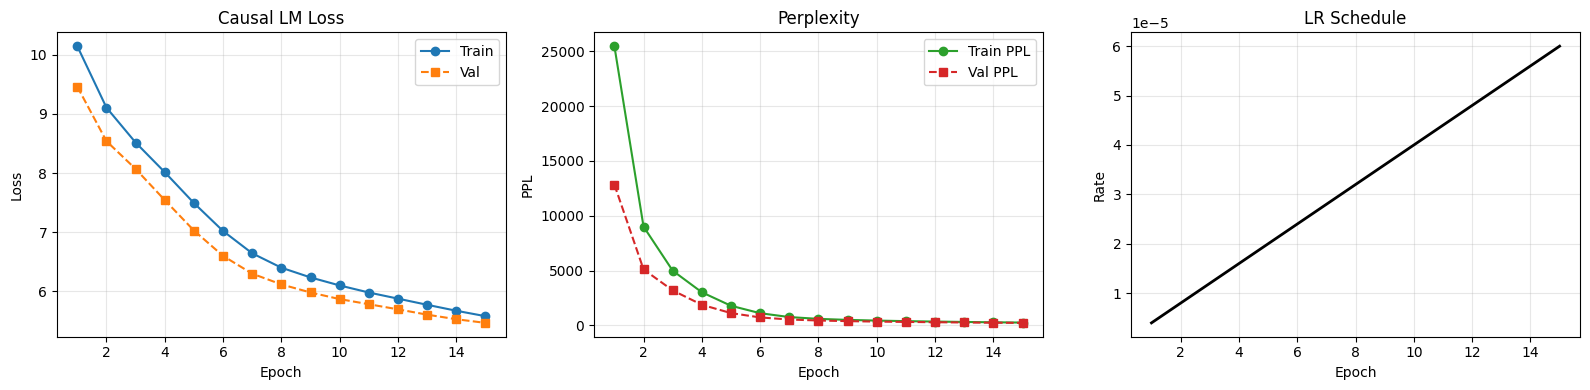

In [30]:
# ==========================================
# 3c. Plot Pre-training Curves
# ==========================================

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
epochs = range(1, len(pretrain_history['train_loss']) + 1)

# Loss
axes[0].plot(epochs, pretrain_history['train_loss'], 'o-', label='Train', color='#1f77b4')
axes[0].plot(epochs, pretrain_history['val_loss'], 's--', label='Val', color='#ff7f0e')
axes[0].set_title('Causal LM Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Perplexity
axes[1].plot(epochs, pretrain_history['train_ppl'], 'o-', label='Train PPL', color='#2ca02c')
axes[1].plot(epochs, pretrain_history['val_ppl'], 's--', label='Val PPL', color='#d62728')
axes[1].set_title('Perplexity')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('PPL')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# LR
axes[2].plot(epochs, pretrain_history['lrs'], label='LR', color='black', linewidth=2)
axes[2].set_title('LR Schedule')
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('Rate')
axes[2].ticklabel_format(style='sci', axis='y', scilimits=(0,0))
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


---
# 4. Phase 2 — Discriminative Fine-tuning on SST-2

GPT-1 fine-tuning key details (from the paper):

1. **Input format:** `[BOS] sentence [CLF]` — the classification token is appended at the **end**
   (since GPT reads left-to-right, the last position has seen the entire sequence).

2. **Auxiliary LM loss:** $L = L_{\text{task}} + \lambda \cdot L_{\text{LM}}$ with $\lambda = 0.5$.
   The LM loss acts as a regularizer, preventing the model from forgetting its pre-trained representations.

3. **Output:** Classification logits are computed from the `[CLF]` token's hidden state.

---


In [19]:
# ==========================================
# 4a. SST-2 Dataset for GPT-1
# ==========================================

class SST2Dataset(Dataset):
    """
    Wraps SST-2 for GPT-1: [BOS] sentence [CLF]
    The [CLF] token at the END is used for classification (GPT reads left-to-right).
    We also return the LM targets (shifted input) for the auxiliary LM loss.
    """
    def __init__(self, hf_dataset, vocab, max_len=128):
        self.data = hf_dataset
        self.vocab = vocab
        self.max_len = max_len

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        item = self.data[idx]
        text = item['sentence']
        label = item['label'] if item['label'] != -1 else 0

        tokens = tokenizer(text)
        token_ids = [self.vocab.get(t, UNK_IDX) for t in tokens]

        # [BOS] sentence [CLF]
        input_ids = [BOS_IDX] + token_ids[:self.max_len - 2] + [CLF_IDX]

        # LM targets: sentence [CLF] (shifted by 1 from input)
        lm_targets = token_ids[:self.max_len - 2] + [CLF_IDX]
        # Pad to match input length (lm_targets should be same length as input_ids)
        while len(lm_targets) < len(input_ids):
            lm_targets.append(-100)
        lm_targets = lm_targets[:len(input_ids)]

        # The position of [CLF] token (last real token)
        clf_position = len(input_ids) - 1

        return (
            torch.tensor(input_ids, dtype=torch.long),
            torch.tensor(lm_targets, dtype=torch.long),
            torch.tensor(label, dtype=torch.long),
            torch.tensor(clf_position, dtype=torch.long),
        )


def sst2_collate_fn(batch):
    input_ids, lm_targets, labels, clf_positions = zip(*batch)
    input_ids = pad_sequence(input_ids, batch_first=True, padding_value=PAD_IDX)
    lm_targets = pad_sequence(lm_targets, batch_first=True, padding_value=-100)
    labels = torch.stack(labels)
    clf_positions = torch.stack(clf_positions)
    return input_ids, lm_targets, labels, clf_positions


# Build DataLoaders
sst2_train_ds = SST2Dataset(sst2_dataset['train'], vocab, max_len=MAX_LEN)
sst2_val_ds = SST2Dataset(sst2_dataset['validation'], vocab, max_len=MAX_LEN)

sst2_train_loader = DataLoader(
    sst2_train_ds, batch_size=FINETUNE_BATCH_SIZE,
    shuffle=True, collate_fn=sst2_collate_fn
)
sst2_val_loader = DataLoader(
    sst2_val_ds, batch_size=FINETUNE_BATCH_SIZE,
    shuffle=False, collate_fn=sst2_collate_fn
)

print(f"SST-2 Train batches: {len(sst2_train_loader)}, Val batches: {len(sst2_val_loader)}")


SST-2 Train batches: 2105, Val batches: 28


In [20]:
# ==========================================
# 4b. GPT-1 Classifier (Fine-tuning wrapper)
# ==========================================

class GPTClassifier(nn.Module):
    """
    GPT-1 Classifier.
    Uses the [CLF] token (last position) hidden state for classification.
    Also returns LM logits for the auxiliary LM loss.
    """
    def __init__(self, gpt_model, d_model, num_classes, dropout=0.1):
        super().__init__()
        self.gpt = gpt_model
        self.classifier = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(d_model, num_classes)
        )

    def forward(self, input_ids, clf_positions):
        # Get hidden states from the full decoder
        hidden = self.gpt.get_hidden_states(input_ids)  # [batch, seq_len, d_model]

        # LM logits (for auxiliary loss)
        lm_logits = self.gpt.lm_head(hidden)  # [batch, seq_len, vocab_size]

        # Classification: extract [CLF] token hidden state per sample
        batch_size = input_ids.size(0)
        clf_hidden = hidden[torch.arange(batch_size, device=input_ids.device), clf_positions]
        cls_logits = self.classifier(clf_hidden)  # [batch, num_classes]

        return cls_logits, lm_logits


In [21]:
# ==========================================
# 4c. Fine-tuning Training & Evaluation Loop
# ==========================================

def evaluate_classifier(model, data_loader, task_criterion, lm_criterion, lm_weight, device):
    model.eval()
    total_loss = 0.0
    all_preds, all_labels = [], []

    with torch.no_grad():
        for input_ids, lm_targets, labels, clf_positions in data_loader:
            input_ids = input_ids.to(device)
            lm_targets = lm_targets.to(device)
            labels = labels.to(device)
            clf_positions = clf_positions.to(device)

            cls_logits, lm_logits = model(input_ids, clf_positions)

            task_loss = task_criterion(cls_logits, labels)
            lm_loss = lm_criterion(lm_logits.view(-1, lm_logits.size(-1)), lm_targets.view(-1))
            # loss = task_loss + lm_weight * lm_loss
            loss = task_loss + (lm_weight * 0.2) * lm_loss

            total_loss += loss.item() * labels.size(0)
            preds = cls_logits.argmax(dim=-1)
            all_preds.extend(preds.cpu().tolist())
            all_labels.extend(labels.cpu().tolist())

    avg_loss = total_loss / len(all_labels)
    acc = accuracy_score(all_labels, all_preds)
    f1 = f1_score(all_labels, all_preds, average='binary')
    return avg_loss, acc, f1, all_preds, all_labels


def finetune_gpt(model, train_loader, val_loader, num_epochs, lr, lm_weight, device, patience=3):
    """
    GPT-1 fine-tuning with auxiliary LM loss.
    L_total = L_task + lambda * L_LM (lambda = 0.5 per the paper).
    """
    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=0.01)
    # scheduler = optim.lr_scheduler.OneCycleLR(
    #     optimizer, max_lr=lr, steps_per_epoch=len(train_loader), epochs=num_epochs
    # )
    warmup_steps = 2000
    total_steps = len(train_loader) * num_epochs

    scheduler = torch.optim.lr_scheduler.SequentialLR(
        optimizer,
        schedulers=[
            torch.optim.lr_scheduler.LinearLR(optimizer, start_factor=1e-8, end_factor=1.0, total_iters=warmup_steps),
            torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=total_steps - warmup_steps)
        ],
        milestones=[warmup_steps]
    )

    task_criterion = nn.CrossEntropyLoss()
    lm_criterion = nn.CrossEntropyLoss(ignore_index=-100)

    use_amp = (device.type == 'cuda')
    scaler = GradScaler('cuda', enabled=use_amp)

    history = {'train_loss': [], 'val_loss': [], 'val_acc': [], 'val_f1': [], 'lrs': []}
    best_val_acc = 0.0
    epochs_no_improve = 0
    start_time = time.time()

    print(f"Fine-tuning GPT-1 on SST-2 ({device})...")
    print(f"Epochs: {num_epochs} | LR: {lr} | Aux LM weight: {lm_weight} | Patience: {patience}")
    print("-" * 90)

    for epoch in range(num_epochs):
        model.train()
        train_loss = 0.0

        for input_ids, lm_targets, labels, clf_positions in train_loader:
            input_ids = input_ids.to(device, non_blocking=True)
            lm_targets = lm_targets.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)
            clf_positions = clf_positions.to(device, non_blocking=True)

            optimizer.zero_grad(set_to_none=True)

            with autocast('cuda', enabled=use_amp):
                cls_logits, lm_logits = model(input_ids, clf_positions)

                task_loss = task_criterion(cls_logits, labels)
                lm_loss = lm_criterion(lm_logits.view(-1, lm_logits.size(-1)), lm_targets.view(-1))
                # loss = task_loss + lm_weight * lm_loss
                loss = task_loss + (lm_weight * 0.2) * lm_loss

            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            scaler.step(optimizer)
            scaler.update()
            scheduler.step()

            train_loss += loss.item()

        # Evaluate
        avg_train_loss = train_loss / len(train_loader)
        val_loss, val_acc, val_f1, _, _ = evaluate_classifier(
            model, val_loader, task_criterion, lm_criterion, lm_weight, device
        )

        current_lr = optimizer.param_groups[0]['lr']
        history['train_loss'].append(avg_train_loss)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)
        history['val_f1'].append(val_f1)
        history['lrs'].append(current_lr)

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            torch.save(model.state_dict(), 'best_gpt1_sst2.pth')
            epochs_no_improve = 0
            status = " * (Saved Best)"
        else:
            epochs_no_improve += 1
            status = f" (No improve: {epochs_no_improve}/{patience})"

        print(f"Epoch {epoch+1:02d}/{num_epochs} | "
              f"Loss (T/V): {avg_train_loss:.4f} / {val_loss:.4f} | "
              f"Acc: {val_acc*100:.2f}% | F1: {val_f1*100:.2f}% | "
              f"LR: {current_lr:.2e}{status}")

        if epochs_no_improve >= patience:
            print(f"\nEarly stopping triggered.")
            break

    print(f"\nFine-tuning complete! Total time: {(time.time()-start_time)/60:.1f} min")
    print(f"Best Val Accuracy: {best_val_acc*100:.2f}%")
    model.load_state_dict(torch.load('best_gpt1_sst2.pth'))
    return history


In [22]:
# ==========================================
# 4d. Initialize & Fine-tune
# ==========================================

set_all_seeds(RANDOM_SEED)

# Load pre-trained weights
gpt_model.load_state_dict(torch.load('gpt1_pretrained.pth', map_location=DEVICE))

# Wrap with classification head
classifier = GPTClassifier(
    gpt_model=gpt_model,
    d_model=D_MODEL,
    num_classes=2,  # SST-2: positive / negative
    dropout=DROPOUT
).to(DEVICE)

print(f"Classifier parameters: {sum(p.numel() for p in classifier.parameters() if p.requires_grad):,}")
print(f"Classifier head: {sum(p.numel() for p in classifier.classifier.parameters()):,} (added on top of pre-trained GPT)")


Classifier parameters: 108,195,842
Classifier head: 1,538 (added on top of pre-trained GPT)


In [23]:
# Run Fine-tuning
finetune_history = finetune_gpt(
    classifier, sst2_train_loader, sst2_val_loader,
    num_epochs=FINETUNE_EPOCHS,
    lr=FINETUNE_LR,
    lm_weight=AUX_LM_WEIGHT,
    device=DEVICE,
    patience=5 #PATIENCE
)


Fine-tuning GPT-1 on SST-2 (cuda)...
Epochs: 5 | LR: 6.25e-05 | Aux LM weight: 0.1 | Patience: 5
------------------------------------------------------------------------------------------
Epoch 01/5 | Loss (T/V): 0.6114 / 0.6221 | Acc: 78.10% | F1: 79.57% | LR: 6.25e-05 * (Saved Best)
Epoch 02/5 | Loss (T/V): 0.4263 / 0.7669 | Acc: 76.95% | F1: 80.39% | LR: 5.27e-05 (No improve: 1/5)
Epoch 03/5 | Loss (T/V): 0.3451 / 0.7799 | Acc: 77.41% | F1: 76.58% | LR: 3.06e-05 (No improve: 2/5)
Epoch 04/5 | Loss (T/V): 0.2853 / 0.6889 | Acc: 79.82% | F1: 79.39% | LR: 8.94e-06 * (Saved Best)
Epoch 05/5 | Loss (T/V): 0.2453 / 0.8371 | Acc: 79.47% | F1: 79.87% | LR: 0.00e+00 (No improve: 1/5)

Fine-tuning complete! Total time: 21.6 min
Best Val Accuracy: 79.82%


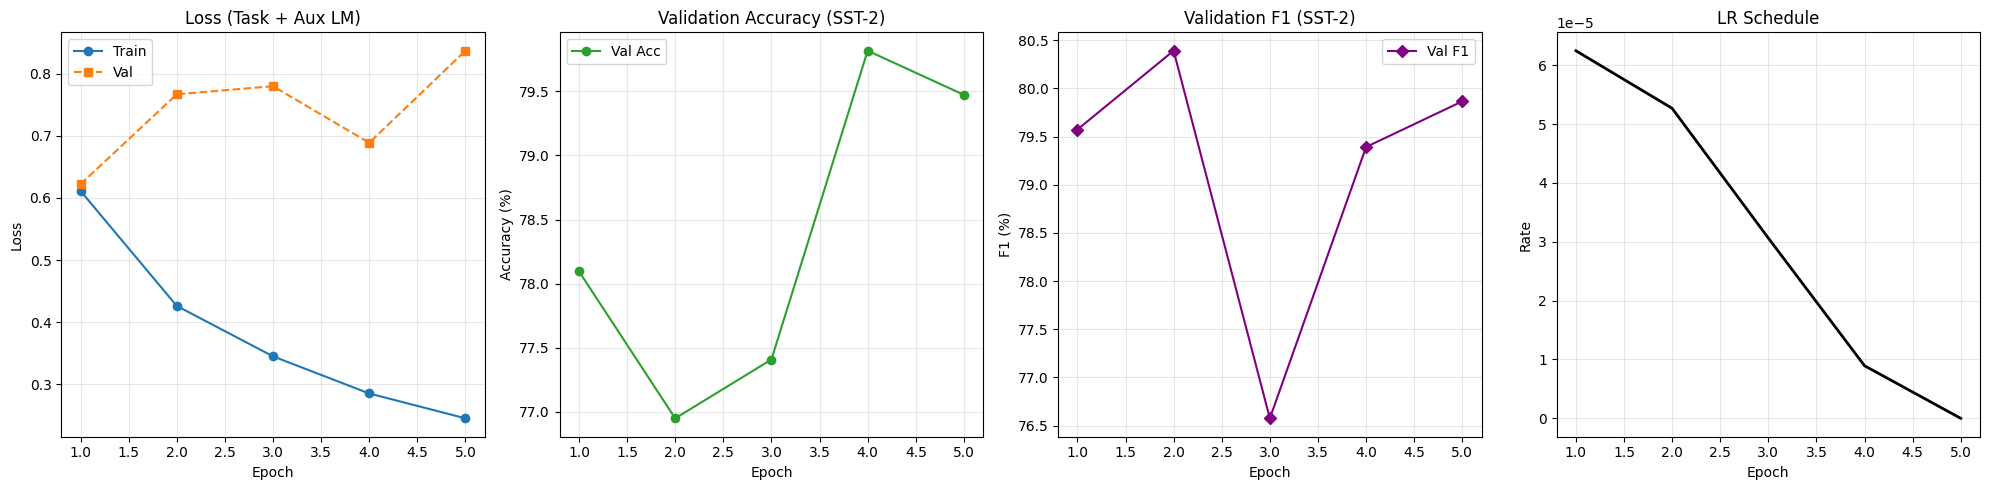

In [24]:
# ==========================================
# 4e. Plot Fine-tuning Curves
# ==========================================

fig, axes = plt.subplots(1, 4, figsize=(20, 5))
epochs = range(1, len(finetune_history['train_loss']) + 1)

axes[0].plot(epochs, finetune_history['train_loss'], 'o-', label='Train', color='#1f77b4')
axes[0].plot(epochs, finetune_history['val_loss'], 's--', label='Val', color='#ff7f0e')
axes[0].set_title('Loss (Task + Aux LM)')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(epochs, [a*100 for a in finetune_history['val_acc']], 'o-', label='Val Acc', color='#2ca02c')
axes[1].set_title('Validation Accuracy (SST-2)')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy (%)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

axes[2].plot(epochs, [f*100 for f in finetune_history['val_f1']], 'D-', label='Val F1', color='purple')
axes[2].set_title('Validation F1 (SST-2)')
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('F1 (%)')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

axes[3].plot(epochs, finetune_history['lrs'], label='LR', color='black', linewidth=2)
axes[3].set_title('LR Schedule')
axes[3].set_xlabel('Epoch')
axes[3].set_ylabel('Rate')
axes[3].ticklabel_format(style='sci', axis='y', scilimits=(0,0))
axes[3].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


---
# 5. Final Evaluation & Audit

---


In [25]:
# ==========================================
# 5a. Full Validation Report
# ==========================================

task_criterion = nn.CrossEntropyLoss()
lm_criterion = nn.CrossEntropyLoss(ignore_index=-100)
val_loss, val_acc, val_f1, all_preds, all_labels = evaluate_classifier(
    classifier, sst2_val_loader, task_criterion, lm_criterion, AUX_LM_WEIGHT, DEVICE
)

print("=" * 60)
print("           FINAL SST-2 VALIDATION AUDIT           ")
print("=" * 60)
print(f"  Loss:     {val_loss:.4f}")
print(f"  Accuracy: {val_acc*100:.2f}%")
print(f"  F1 Score: {val_f1*100:.2f}%")
print("=" * 60)

print("\nClassification Report:")
print(classification_report(all_labels, all_preds, target_names=['Negative', 'Positive']))


           FINAL SST-2 VALIDATION AUDIT           
  Loss:     0.6889
  Accuracy: 79.82%
  F1 Score: 79.39%

Classification Report:
              precision    recall  f1-score   support

    Negative       0.77      0.83      0.80       428
    Positive       0.83      0.76      0.79       444

    accuracy                           0.80       872
   macro avg       0.80      0.80      0.80       872
weighted avg       0.80      0.80      0.80       872



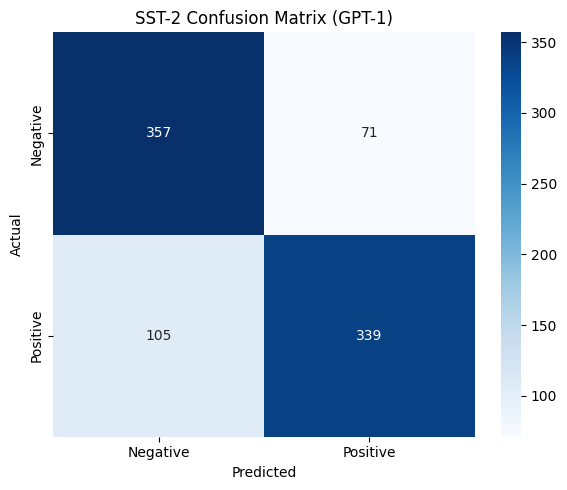

In [26]:
# ==========================================
# 5b. Confusion Matrix
# ==========================================

cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Negative', 'Positive'],
            yticklabels=['Negative', 'Positive'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('SST-2 Confusion Matrix (GPT-1)')
plt.tight_layout()
plt.show()


---
# 6. Text Generation & Sentiment Prediction

Unlike BERT, GPT-1 can **generate text** autoregressively.

---


In [27]:
# ==========================================
# 6a. Autoregressive Text Generation
# ==========================================

def generate_text(model, prompt, vocab, inv_vocab, device, max_gen=50, temperature=0.8, top_k=40):
    """Generate text autoregressively from a prompt using the pre-trained GPT model."""
    model.eval()

    # Use the base GPT model (not the classifier wrapper)
    gpt = model.gpt if hasattr(model, 'gpt') else model

    tokens = [BOS_IDX] + [vocab.get(t, UNK_IDX) for t in tokenizer(prompt)]
    generated = list(tokens)

    for _ in range(max_gen):
        input_ids = torch.tensor([generated[-MAX_LEN:]], dtype=torch.long).to(device)

        with torch.no_grad():
            logits = gpt(input_ids)

        next_logits = logits[0, -1, :] / temperature

        # Top-k filtering
        if top_k > 0:
            indices_to_remove = next_logits < torch.topk(next_logits, top_k)[0][-1]
            next_logits[indices_to_remove] = float('-inf')

        probs = F.softmax(next_logits, dim=-1)
        next_token = torch.multinomial(probs, num_samples=1).item()

        if next_token == EOS_IDX:
            break

        generated.append(next_token)

    # Decode
    output_tokens = [inv_vocab.get(t, '[UNK]') for t in generated[1:]]  # Skip [BOS]
    return ' '.join(output_tokens)


# Generate from several prompts
prompts = [
    "the history of",
    "in the beginning",
    "scientists have discovered",
    "the president announced",
]

print("=" * 80)
print("GPT-1 Text Generation (Top-k sampling, temp=0.8)")
print("=" * 80)
for prompt in prompts:
    output = generate_text(classifier, prompt, vocab, inv_vocab, DEVICE)
    print(f"\nPrompt: \"{prompt}\"\n  → {output}")
print()


GPT-1 Text Generation (Top-k sampling, temp=0.8)

Prompt: "the history of"
  → the history of the most [UNK] - - film in [UNK] of the film that it 's [UNK] of his way , and [UNK] , [CLF] [CLF] [CLF] in the own [CLF] [CLF] - of which it 's [UNK] [CLF] a [UNK] [UNK] and [UNK] [CLF] [CLF] has , and you [CLF] and

Prompt: "in the beginning"
  → in the beginning [CLF] of its [UNK] and [UNK] , [UNK] , a [UNK] , [CLF] [CLF] and the film of the [UNK] [CLF] in this director . [CLF] is of the best . [CLF] . [CLF] . [CLF] that is , but , [UNK] . [CLF] , and [CLF] and the most

Prompt: "scientists have discovered"
  → scientists have discovered [CLF] [CLF] , it 's the time for the most of a [UNK] [CLF] a [UNK] . [CLF] in its [UNK] [CLF] is [UNK] , [CLF] [CLF] of the screen 's a new - - - - - and [UNK] - that it 's best - - - - -

Prompt: "the president announced"
  → the president announced [CLF] one of the [UNK] and [UNK] [CLF] of the first , and [UNK] and [UNK] [CLF] to be an [UNK] [CLF] to be a

In [28]:
# ==========================================
# 6b. Qualitative Sentiment Predictions
# ==========================================

def predict_sentiment(text, model, vocab, device, max_len=MAX_LEN):
    """Run sentiment inference on a single sentence using GPT-1 classifier."""
    model.eval()
    tokens = tokenizer(text)
    token_ids = [BOS_IDX] + [vocab.get(t, UNK_IDX) for t in tokens][:max_len-2] + [CLF_IDX]
    clf_position = len(token_ids) - 1

    input_ids = torch.tensor([token_ids], dtype=torch.long).to(device)
    clf_pos = torch.tensor([clf_position], dtype=torch.long).to(device)

    with torch.no_grad():
        cls_logits, _ = model(input_ids, clf_pos)
        probs = F.softmax(cls_logits, dim=-1)
        pred = cls_logits.argmax(dim=-1).item()

    label = "Positive" if pred == 1 else "Negative"
    confidence = probs[0, pred].item()
    return label, confidence


test_sentences = [
    "This movie was absolutely wonderful and a delight to watch.",
    "A terrible waste of time, poorly written and badly acted.",
    "The food was okay, nothing special but not bad either.",
    "An incredible performance that moved me to tears.",
    "I was bored out of my mind during this awful film.",
    "A solid effort with great cinematography and decent acting.",
    "The worst experience I have ever had at a restaurant.",
    "Absolutely brilliant, a masterpiece of modern cinema.",
]

print(f"{'Sentence':<60} | {'Prediction':<10} | {'Confidence'}")
print("-" * 90)
for sent in test_sentences:
    label, conf = predict_sentiment(sent, classifier, vocab, DEVICE)
    display = sent[:57] + "..." if len(sent) > 57 else sent
    print(f"{display:<60} | {label:<10} | {conf:.2%}")


Sentence                                                     | Prediction | Confidence
------------------------------------------------------------------------------------------
This movie was absolutely wonderful and a delight to watc... | Positive   | 99.88%
A terrible waste of time, poorly written and badly acted.    | Negative   | 99.84%
The food was okay, nothing special but not bad either.       | Negative   | 92.66%
An incredible performance that moved me to tears.            | Positive   | 99.92%
I was bored out of my mind during this awful film.           | Negative   | 99.66%
A solid effort with great cinematography and decent actin... | Positive   | 99.90%
The worst experience I have ever had at a restaurant.        | Negative   | 96.38%
Absolutely brilliant, a masterpiece of modern cinema.        | Positive   | 99.90%


---
# Summary

---

In this notebook, I implemented **GPT-1** (Generative Pre-trained Transformer) from scratch,
using a **decoder-only** architecture with **causal self-attention**.

**Phase 1 (Pre-training):** The model was pre-trained on WikiText-2 (as a BookCorpus proxy)
with a standard autoregressive language modeling objective — predict the next token.

**Phase 2 (Fine-tuning):** The pre-trained model was fine-tuned on **SST-2** for sentiment
classification using the `[CLF]` token, with an **auxiliary LM loss** ($\lambda = 0.5$)
to preserve the model's learned representations.

Unlike BERT, GPT-1 can also **generate text** autoregressively after pre-training.

<br>

### Key Architectural Differences: BERT vs GPT-1

| Feature | BERT | GPT-1 |
| :--- | :--- | :--- |
| **Direction** | Bidirectional | Left-to-right (causal) |
| **Mask** | Padding only | **Causal** (lower triangular) |
| **Pre-training** | MLM + NSP | **Autoregressive LM** |
| **Fine-tuning head** | On `[CLS]` (pos 0) | On `[CLF]` (**last** position) |
| **Auxiliary loss** | None | **$\lambda \cdot L_{LM}$** |
| **Weight tying** | No | **Yes** (LM head = embedding) |
| **Can generate** | No | **Yes** |

### Architectural Evolution Path

| Step | Architecture | Key Innovation | Primary Task |
| :--- | :--- | :--- | :--- |
| 1 | Seq2Seq (LSTM/GRU) | Recurrent encoding | Translation |
| 2 | Seq2Seq + Attention | Dynamic alignment | Translation |
| 3 | **Transformer** | Self-Attention / Parallelism | Translation |
| 4 | **BERT** | Bidirectional + Self-Supervised | Classification / QA |
| 5 | **GPT-1** (this notebook) | Causal LM + Discriminative Fine-tuning | **Classification + Generation** |

---


In [29]:
%watermark -iv


datasets  : 4.0.0
matplotlib: 3.10.0
numpy     : 2.0.2
re        : 2.2.1
seaborn   : 0.13.2
sklearn   : 1.6.1
torch     : 2.10.0+cu128
torchinfo : 1.8.0

